In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [22]:
data_path = '/kaggle/input/datasets/tushaamagrawal/icbhi-2017-challenge/ICBHI_final_database'

total_files = os.listdir(data_path)

print("Total files are:",len(total_files))

# we would check now to see if no. of .wav and .txt files are matching or not

wav_files = [f for f in total_files if f.endswith(".wav")]
txt_files = [f for f in total_files if f.endswith(".txt")]

print("Total .wav files:",len(wav_files))  #920
print("Total .txt files:",len(txt_files))  #922

#so mismatch is there, we need to use only those which have both .wav and .txt

wav_set = set([f.replace(".wav", "") for f in wav_files])
txt_set = set([f.replace(".txt","") for f in txt_files])

common_files = list(wav_set.intersection(txt_set))

print("Usable files:", len(common_files))

missing_txt = wav_set - txt_set
missing_wav = txt_set - wav_set

print("Total wav files without txt files:",missing_txt)
print("Total txt files without wav files:",missing_wav)

Total files are: 1843
Total .wav files: 920
Total .txt files: 922
Usable files: 920
Total wav files without txt files: set()
Total txt files without wav files: {'filename_differences', 'filename_format'}


In [23]:
from sklearn.model_selection import train_test_split

train_files, test_files = train_test_split(common_files, test_size=0.2, random_state=42)
train_files, val_files  = train_test_split(train_files, test_size=0.2, random_state=42)

In [24]:
def add_noise(signal):
    noise = np.random.randn(len(signal))
    return signal + 0.005 * noise

def time_shift(signal):
    shift = int(np.random.uniform(-0.2, 0.2) * len(signal))
    return np.roll(signal, shift)

def volume_scale(signal):
    return signal * np.random.uniform(0.8, 1.2)

In [25]:
def augment_signal(signal, sr=16000):
    augmented = []
    augmented.append(signal)                     # original
    augmented.append(add_noise(signal))          # noise
    augmented.append(time_shift(signal))         # shift
    try:
        augmented.append(time_stretch(signal, rate=np.random.uniform(0.9, 1.1)))
    except:
        pass
    try:
        augmented.append(pitch_shift(signal, sr, n_steps=np.random.uniform(-1,1)))
    except:
        pass
    return augmented

In [26]:
def to_mel_spec(seg, sr=16000, n_mels=128):
    mel = librosa.feature.melspectrogram(y=seg, sr=sr, n_mels=n_mels)
    return librosa.power_to_db(mel)

def pad_spec(spec, target_time=128):
    if spec.shape[1] < target_time:
        pad = target_time - spec.shape[1]
        spec = np.pad(spec, ((0,0), (0,pad)))
    else:
        spec = spec[:, :target_time]
    return spec

def get_label(crackle, wheeze):
    if crackle == 0 and wheeze == 0: return 0
    elif crackle == 1 and wheeze == 0: return 1
    elif crackle == 0 and wheeze == 1: return 2
    else: return 3

In [27]:
def build_spectrogram_dataset(file_list, augment=False):
    X = []
    y = []
    file_ids = []
    sr = 16000
    for file in file_list:
        wav_path = os.path.join(data_path, file + '.wav')
        txt_path = os.path.join(data_path, file + '.txt')
        if not os.path.exists(wav_path) or not os.path.exists(txt_path):
            continue
        audio, sr = librosa.load(wav_path, sr=sr)
        annotations = pd.read_csv(txt_path, sep='\t', names=['start', 'end', 'crackle', 'wheeze'])
        for _, row in annotations.iterrows():
            start = int(row['start'] * sr)
            end   = int(row['end'] * sr)
            segment = audio[start:end]
            if len(segment) < 1000:
                continue
            label = get_label(row['crackle'], row['wheeze'])
            if augment:
                aug_segments = augment_signal(segment, sr)
                for aug_seg in aug_segments:
                    if len(aug_seg) >= 1000:
                        spec = pad_spec(to_mel_spec(aug_seg, sr))
                        X.append(spec)
                        y.append(label)
                        file_ids.append(file)
            else:
                spec = pad_spec(to_mel_spec(segment, sr))
                X.append(spec)
                y.append(label)
                file_ids.append(file)
    X = np.array(X)[..., np.newaxis]      # add channel dimension
    y = np.array(y)
    return X, y, file_ids

In [28]:
X_train, y_train, _ = build_spectrogram_dataset(train_files, augment=True)
print(f"Train spectrograms shape: {X_train.shape}")

X_val, y_val, _ = build_spectrogram_dataset(val_files, augment=False)
print(f"Val spectrograms shape: {X_val.shape}")

X_test, y_test, test_ids = build_spectrogram_dataset(test_files, augment=False)
print(f"Test spectrograms shape: {X_test.shape}")

Train spectrograms shape: (13353, 128, 128, 1)
Val spectrograms shape: (1056, 128, 128, 1)
Test spectrograms shape: (1391, 128, 128, 1)


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Reshape, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


input_layer = Input(shape=(128, 128, 1))

# CNN feature extractor
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
x = MaxPooling2D((2,2))(x)
x = BatchNormalization()(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = BatchNormalization()(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = BatchNormalization()(x)

# Reshape for BiLSTM
shape = x.shape
x = Reshape((shape[2], shape[1] * shape[3]))(x)
x = Bidirectional(LSTM(64, return_sequences=False))(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(4, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 16, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │     1,081,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,183,940 (4.52 MB)

 Trainable params: 1,183,492 (4.51 MB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
from collections import defaultdict

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# CELL 9: Segment‑level predictions and file‑level aggregation
y_pred_prob = model.predict(X_test)

# Aggregate to file level (same method as YAMNET)
file_preds = defaultdict(list)
file_true = {}

for prob, label, fid in zip(y_pred_prob, y_test, test_ids):
    file_preds[fid].append(prob)
    file_true[fid] = label  # all segments from same file have same label

y_true_file = []
y_pred_file = []

for fid in file_preds:
    probs = np.array(file_preds[fid])
    # Confidence‑weighted top‑k aggregation
    conf = np.max(probs, axis=1)
    k = max(1, len(probs) // 3)
    top_idx = np.argsort(conf)[-k:]
    top_probs = probs[top_idx]
    top_conf = conf[top_idx]
    weights = top_conf / np.sum(top_conf)
    final_prob = np.sum(top_probs * weights[:, None], axis=0)
    pred = np.argmax(final_prob)
    y_pred_file.append(pred)
    y_true_file.append(file_true[fid])



Epoch 1/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.4998 - loss: 1.1505 - val_accuracy: 0.5663 - val_loss: 1.0099
Epoch 2/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.5864 - loss: 0.9798 - val_accuracy: 0.5956 - val_loss: 0.9612
Epoch 3/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.6348 - loss: 0.8821 - val_accuracy: 0.5909 - val_loss: 0.9552
Epoch 4/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.6853 - loss: 0.7738 - val_accuracy: 0.6222 - val_loss: 0.9465
Epoch 5/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7361 - loss: 0.6762 - val_accuracy: 0.6316 - val_loss: 0.9161
Epoch 6/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7984 - loss: 0.5458 - val_accuracy: 0.6269 - val_loss: 0.9489
Epoch 7/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.8347 - loss: 0.4531 - val_accuracy: 0.6212 - val_loss: 0.9854
Epoch 8/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.8796 - loss: 0.3469 - 


 🚀 CNN-BiLSTM: PERFORMANCE METRICS
Accuracy:      0.6522
Macro F1:      0.5051
Weighted F1:   0.6421
-----------------------------------

Classification Report:

              precision    recall  f1-score   support

      Normal       0.73      0.79      0.76       107
     Crackle       0.55      0.55      0.55        47
      Wheeze       0.42      0.31      0.36        16
        Both       0.44      0.29      0.35        14

    accuracy                           0.65       184
   macro avg       0.54      0.49      0.51       184
weighted avg       0.64      0.65      0.64       184



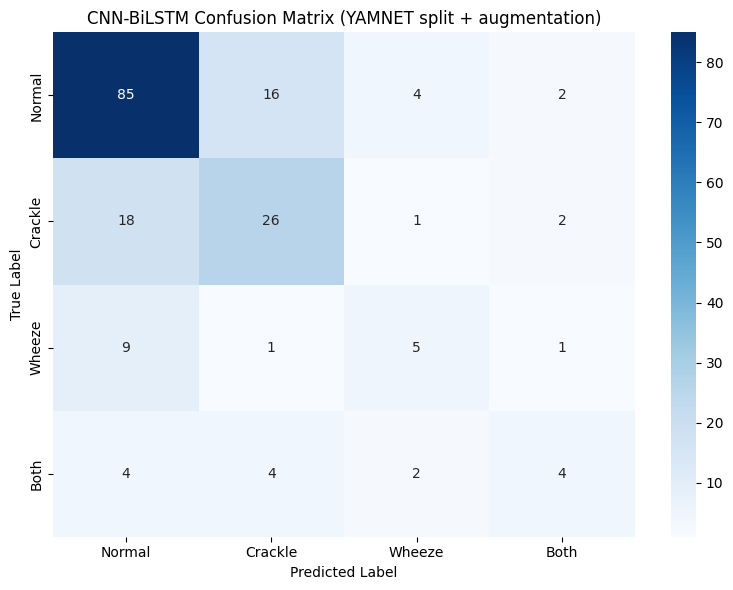

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
class_names = ['Normal', 'Crackle', 'Wheeze', 'Both']
acc = accuracy_score(y_true_file, y_pred_file)
macro_f1 = f1_score(y_true_file, y_pred_file, average='macro')
weighted_f1 = f1_score(y_true_file, y_pred_file, average='weighted')

print("\n" + "="*35)
print(" 🚀 CNN-BiLSTM: PERFORMANCE METRICS")
print("="*35)
print(f"Accuracy:      {acc:.4f}")
print(f"Macro F1:      {macro_f1:.4f}")
print(f"Weighted F1:   {weighted_f1:.4f}")
print("-"*35)

print("\nClassification Report:\n")
print(classification_report(y_true_file, y_pred_file, target_names=class_names, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_true_file, y_pred_file)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("CNN-BiLSTM Confusion Matrix (YAMNET split + augmentation)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [34]:
model.save("/kaggle/working/Aero_BiLSTM.keras")
print("Model saved to /kaggle/working/Aero_BiLSTM.keras")

# Save mean/std for inference (though not used in this model, kept for consistency)
mean = np.mean(X_train, axis=0)
std  = np.std(X_train, axis=0) + 1e-8
np.save("/kaggle/working/mean.npy", mean)
np.save("/kaggle/working/std.npy", std)


Model saved to /kaggle/working/Aero_BiLSTM.keras
